In [4]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [2]:
z500=xr.open_dataset('data/era5_zg.nc')

In [3]:
zg = z500.rename({'valid_time': 'time', 'latitude':'lat', 'longitude':'lon'})
zg_x = zg.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2025'),lat=slice(0,-90))

display(zg_x)

/tmp/ipykernel_581752/2794139502.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  zg_x = zg.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2025'),lat=slice(0,-90))


<xarray.DataArray 'z' (time: 901, lat: 361, lon: 1440)> Size: 2GB
[468375840 values with dtype=float32]
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2025-01-01
  * lat      (lat) float64 3kB 0.0 -0.25 -0.5 -0.75 ... -89.5 -89.75 -90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    expver   (time) <U4 14kB ...
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      519840
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                               m**2 s**-2
    long_name:                                Geopotential
    units:                                    m**2 s**-2
    standard_name:                            geopotential

In [5]:
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def var_prepper(da, months_list, wghts_bool=True):
    da_sel=extract_seasonal_data(da, months_list)
    ##1 Anomalies
    da_an=compute_anomaly(da_sel)
    print('Anomalies computed')
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    print('Data is detrended')
    ##cut the weight by latitude part
    da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season= da_wght #extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    #da_masked=sea_mask(da_season_mean) #not necessary for 500hPa?
    da_masked=da_season_mean.to_dataset(name='Z500')
    return da_masked

In [ ]:
z500_SON=var_prepper(zg_x, [9,10,11])

In [ ]:
z500_DJF=var_prepper(zg_x,[12,1,2])

Anomalies computed
Data is detrended


C:\Users\giuli\AppData\Local\Temp\ipykernel_19232\1287881569.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_19232\1287881569.py:40: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be 

In [69]:
years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

z500_SON=exclude_years_xr(z500_SON, years_to_drop)

cut_years=[1950,2003,2020,2025]
z500_DJF=exclude_years_xr(z500_DJF, cut_years)

In [ ]:
display(z500_DJF)

path='ERA5_dyn_data_ready/'
z500_SON.to_netcdf(path=path+'z500_SON.nc', format='NETCDF4')
z500_DJF.to_netcdf(path=path+'z500_DJF.nc', format='NETCDF4')

NameError: name 'z500_SON' is not defined

In [7]:
z500_SON=xr.open_dataset('ERA5_dyn_data_ready/z500_SON.nc')
z500_DJF=xr.open_dataset('ERA5_dyn_data_ready/z500_DJF.nc')

Import driver data

In [8]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('data_ready/4.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 6kB
Dimensions:        (year: 72)
Coordinates:
  * year           (year) int64 576B 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t_Andes        (year) float64 576B -1.791 0.5614 -0.2617 ... 0.7645 0.6017
    precip_Andes   (year) float64 576B 0.129 0.4549 -1.375 ... -0.2223 -1.51
    ENSO           (year) float64 576B -0.6866 0.5838 0.3068 ... -0.7546 1.632
    IOD            (year) float64 576B 0.2555 0.6281 1.26 ... 0.9651 4.209
    EDJ            (year) float64 576B 1.783 0.6677 -0.5056 ... 0.9377 0.1875
    EDJ_lat        (year) float64 576B -0.6985 1.359 -0.9556 ... -2.241 -2.241
    EDJ_lat_nostd  (year) float64 576B -52.07 -48.64 -52.5 ... -54.64 -54.64
    SPV            (year) float64 576B 0.2633 -0.6312 1.451 ... 2.242 1.702 1.85
    A_SAM          (year) float64 576B 0.233 -1.135 -2.197 ... 1.774 0.05365
    S_SAM          (year) float64 576B 0.6038 -1.058 0.1437 ... 1.631 1.93 1.88

In [9]:
##SON data
ds_SON = xr.merge([z500_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([z500_DJF, era_DJF_LaPlata_array])

In [10]:
display(ds_SON)

<xarray.Dataset> Size: 299MB
Dimensions:         (lat: 361, lon: 1440, year: 72)
Coordinates:
  * lat             (lat) float64 3kB 0.0 -0.25 -0.5 ... -89.5 -89.75 -90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    Z500            (year, lat, lon) float64 299MB ...
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

Regressions and Maps

In [11]:
def lin_model_xr(y, x_main, *x_controls):
    """
    y         : (year,)
    x_main    : (year,)   → main predictor (e.g. ENSO)
    x_controls: (year,)   → control predictors
    """

    X_list = [x_main]
    for x in x_controls:
        X_list.append(x)

    X = np.stack(X_list, axis=1)

    model = sm.OLS(y, X).fit()

    coef = model.params[0]
    pval = model.pvalues[0]

    return coef, pval


def construct_da_x_year_fix(da, year_fix=30):
    """
    Construct dictionary of rolling windows of length `year_fix` along time.

    Parameters
    ----------
    da : xarray.DataArray
        Input data with 'time' coordinate
    year_fix : int
        Number of years in each window

    Returns
    -------
    dict
        Keys: end year of window (int)
        Values: xarray.DataArray of shape (year_fix, ...)
    """
    df_dict = {}
    times = da.year.values
    n = len(times)

    for i in range(n - year_fix + 1):
        window = da.isel(year=slice(i, i + year_fix))
        end_year = int(window.year.values[-1])  # last year in window
        df_dict[end_year] = window

    return df_dict

def sensitivity_analysis2(dict_30, target, dep_var, indep_var_list=None, filename=None):
    coefs = []
    pvals = []
    years_end = []

    for year, ds in dict_30.items():

        # target (lat, lon, year)
        y = ds[target] 
        x=ds[dep_var] #driver variable
        # predictors (year,) or (lat, lon, year)
        if indep_var_list is not None:
            predictors = [ds[var] for var in indep_var_list] #controlled vars
        else:
            predictors=[]
        coef, pval = xr.apply_ufunc(
            lin_model_xr,
            y,
            x,
            *predictors,                          # <-- unpack list
            input_core_dims=[["year"]]*(2+len(predictors)),
            output_core_dims=[[], []],
            vectorize=True,
            output_dtypes=[float, float],
        )

        coefs.append(coef) #get slope
        pvals.append(pval) #get significance
        years_end.append(year)

    coef_da = xr.concat(coefs, dim="year").assign_coords(year=years_end)
    pval_da = xr.concat(pvals, dim="year").assign_coords(year=years_end)

    return coef_da, pval_da

def conditioning_everything3(somedict, driver_list, dep_var, skip=True, total_eff=False, filename=None):
    data_list=[]
    #name=dict_namer(somedict)
    #fig, axes=plt.subplots(nrows=1, ncols=len(driver_list), figsize=(8*len(driver_list)+4,8))
    for i, driver in enumerate(driver_list):
        to_be_removed=[driver]
        if total_eff==False: ##estimate direct effect
            driver_mod=[item for item in driver_list if item not in to_be_removed ]
            #print(driver_mod)
            if 'A_SAM' in driver_list and (driver=='SPV' or driver=='S_SAM'):
                driver_mod.remove('A_SAM')
            elif 'SPV' in driver_list and driver=='A_SAM':
                driver_mod.remove('SPV')
                driver_mod.remove('S_SAM')
        else: ## estimate total effect
            if driver=='IOD':
                driver_mod=['ENSO']
            elif driver=='SPV':
                driver_mod=['ENSO', 'IOD']
            else:
                driver_mod=None
                
        if skip==True:
            a=sensitivity_analysis2(somedict,dep_var,driver,driver_mod)
            print(driver+' is done.')
            mean=a[0].mean(dim='year')
            data_list.append(mean)
        else:
            a=somedict[i]
            
        if filename!=None:
            path='Netcdf_maps/'+filename+'/'+driver+'.nc'
            for element in data_list:
                element.to_netcdf(path=path, format='NETCDF4')
        #ax=axes[i] if len(driver_list) > 1 else axes[0]
        #hist_plot3(a, ax, dep_var)
        #plt.savefig(dep_var+str(list(name.keys()))+'3.jpg', bbox_inches='tight')
    return data_list

In [12]:
import cartopy.feature as cfeature

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap, shading="auto")

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.coolwarm, unit='K', cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
        
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    levels = np.linspace(-global_max, global_max, 7)  
    # → 10 color bins (adjust as you like)
    
    if not cbar_each:
        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
        
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('maps/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [13]:
z500_30_years_SON=construct_da_x_year_fix(ds_SON)
z500_30_years_DJF=construct_da_x_year_fix(ds_DJF)

In [14]:
z500_ENSO_SON=sensitivity_analysis2(z500_30_years_SON, 'Z500', 'ENSO')
z500_ENSO_SON_mean=z500_ENSO_SON[0].mean(dim='year')

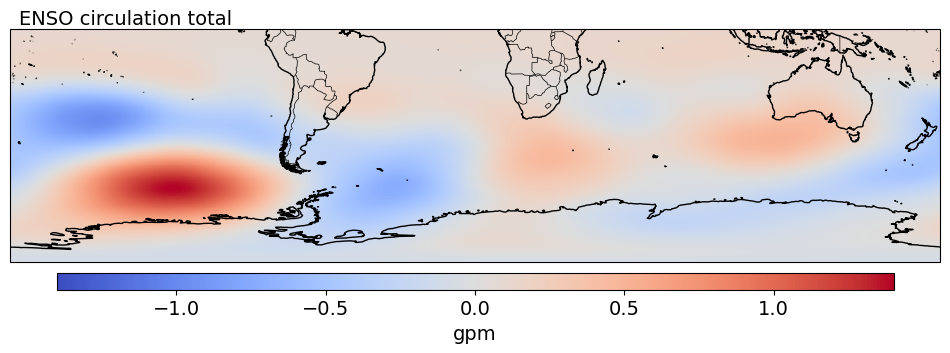

In [18]:
plot_map(1, z500_ENSO_SON_mean, 'ENSO circulation total', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps/ENSO_Z500_total.jpg')